# Análisis del flow-matching de pi0 — ¿hay clusters?

Analiza el CSV de denoising (`output/pi0_denoise/denoise_log.csv`) generado por
`models/Pi_zero/patches.py`. Cada fila es el vector `x_t` en un paso del
flow-matching; `iteration=0` es el ruido inicial y la última iteración de cada
`call` es la **acción final**.

**Objetivo:** ver si, dado el *mismo input*, las acciones finales de las distintas
corridas forman **clusters claros** (señal de una política multimodal).

**Método:** estado final por corrida → reducción a 2D (PCA y t-SNE) → clustering
(KMeans) con *silhouette* para cuantificar qué tan marcados son los clusters.

> Ejecuta este notebook con el entorno conda **`tipico`** (necesita `pandas`,
> `scikit-learn` y `matplotlib`). Si el kernel no aparece seleccionado, elígelo
> a mano (Kernel → Change Kernel).

## 1. Cargar el CSV

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del CSV descargado (ajústala si lo guardaste en otro lugar).
CSV_PATH = "output/pi0_denoise/denoise_log.csv"
assert os.path.exists(CSV_PATH), f"No encuentro el CSV en {CSV_PATH!r}. Ajusta CSV_PATH."

df = pd.read_csv(CSV_PATH)
feat_cols = [c for c in df.columns if c.startswith("v") and c[1:].isdigit()]
print("filas:", len(df), "| columnas de features (v*):", len(feat_cols))
print("nº de corridas (call):", df["call"].nunique())
print("iteraciones por corrida (num_steps):", sorted(df["num_steps"].unique()))
df.head()

filas: 8250 | columnas de features (v*): 1600
nº de corridas (call): 750
iteraciones por corrida (num_steps): [np.int64(10)]


,step,call,batch,iteration,time,num_steps,v0,v1,v2,v3,...,v1590,v1591,v1592,v1593,v1594,v1595,v1596,v1597,v1598,v1599
0,0,1,0,0,1.0,10,2.235115,0.884843,0.862914,1.273971,...,0.968819,-1.252909,1.292511,0.250549,-0.454919,-0.279740,-0.090284,0.543475,-0.159779,-0.506193
1,0,1,0,1,0.9,10,1.983680,0.744152,0.790450,1.154480,...,0.921656,-1.207559,1.177013,0.340397,-0.481842,-0.218257,0.026536,0.602472,0.049247,-0.485019
2,0,1,0,2,0.8,10,1.740717,0.605853,0.716102,1.034340,...,0.863042,-1.166644,1.068934,0.451698,-0.496602,-0.147957,0.137702,0.656482,0.278205,-0.465737
3,0,1,0,3,0.7,10,1.511782,0.476682,0.649203,0.910416,...,0.794793,-1.123037,0.965107,0.570581,-0.502482,-0.078337,0.246228,0.700061,0.516746,-0.444469
4,0,1,0,4,0.6,10,1.288320,0.356263,0.583674,0.779364,...,0.714976,-1.080841,0.866991,0.698997,-0.504523,-0.012805,0.356671,0.742123,0.757047,-0.417387


## 2. Estado final de cada corrida

La **acción final** es la última iteración de cada `call` (tiempo t ≈ 0).
Quitamos las columnas constantes (dimensiones *padded* del vector de acción o sin
variación): no aportan al clustering.

In [19]:
final_iter = df.groupby("call")["iteration"].transform("max")
finals = df[df["iteration"] == final_iter].sort_values("call").reset_index(drop=True)
X = finals[feat_cols].to_numpy(dtype=float)

std = X.std(axis=0)
nonconst = std > 1e-8                      # máscara de dims con variación
X = X[:, nonconst]
print("acciones finales:", X.shape[0], "| dimensiones con variación:", X.shape[1])
if X.shape[0] < 5:
    print("\n[AVISO] Muy pocas corridas para un estudio de clusters robusto.",
          "Sube N en la celda de experimento del notebook de pi0.")

acciones finales: 750 | dimensiones con variación: 1600


## 3. Reducción a 2D con PCA

Estandarizamos (media 0, varianza 1) y proyectamos a 2 componentes. La *varianza
explicada* indica cuánto de la estructura real cabe en el plano 2D.

varianza explicada: [0.065 0.024] -> total 2D: 0.089


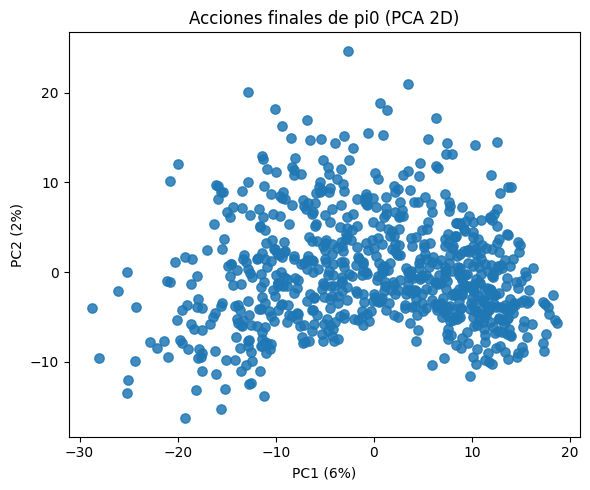

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xs)
evr = pca.explained_variance_ratio_
print("varianza explicada:", evr.round(3), "-> total 2D:", round(evr.sum(), 3))

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], s=45, alpha=0.85)
plt.xlabel(f"PC1 ({evr[0]:.0%})"); plt.ylabel(f"PC2 ({evr[1]:.0%})")
plt.title("Acciones finales de pi0 (PCA 2D)")
plt.tight_layout(); plt.show()

## 4. ¿Cuántos clusters? KMeans + silhouette

Probamos varios `k` y medimos el *silhouette score* (qué tan separados y compactos
son los clusters). Regla práctica:

| silhouette | lectura |
|---|---|
| > 0.50 | estructura de clusters **fuerte** |
| 0.25 – 0.50 | estructura **débil** |
| < 0.25 | **sin** clusters claros (salida ~unimodal / continua) |

silhouette por k: {2: np.float64(0.045), 3: np.float64(0.025), 4: np.float64(0.02), 5: np.float64(0.015), 6: np.float64(0.018)}
mejor k = 2  (silhouette = 0.045)


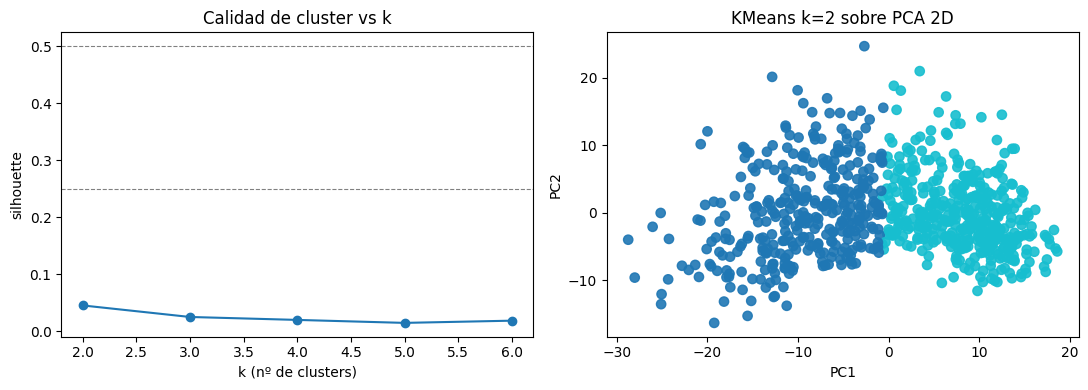

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

n = X.shape[0]
ks = [k for k in range(2, 7) if k < n]
sil = {}
for k in ks:
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    sil[k] = silhouette_score(Xs, lab)
print("silhouette por k:", {k: round(v, 3) for k, v in sil.items()})

best_k = max(sil, key=sil.get) if sil else 1
if sil:
    print(f"mejor k = {best_k}  (silhouette = {sil[best_k]:.3f})")

labels = (KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(Xs)
          if best_k >= 2 else np.zeros(n, dtype=int))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
if ks:
    ax[0].plot(list(sil), list(sil.values()), "o-")
    ax[0].axhline(0.25, ls="--", c="gray", lw=0.8)
    ax[0].axhline(0.50, ls="--", c="gray", lw=0.8)
    ax[0].set_xlabel("k (nº de clusters)"); ax[0].set_ylabel("silhouette")
    ax[0].set_title("Calidad de cluster vs k")
ax[1].scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=45, alpha=0.9)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title(f"KMeans k={best_k} sobre PCA 2D")
plt.tight_layout(); plt.show()

## 5. t-SNE (no lineal)

PCA es lineal; t-SNE puede revelar clusters que PCA no separa. Coloreamos con los
clusters de KMeans para comparar. La `perplexity` se ajusta al nº de muestras.

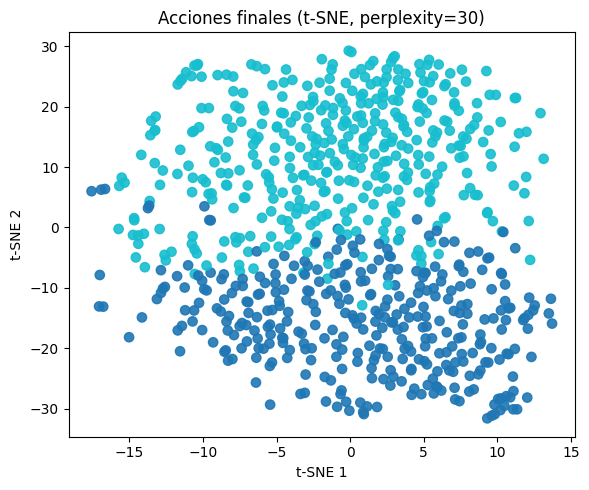

In [22]:
from sklearn.manifold import TSNE

if n >= 5:
    perp = max(2, min(30, (n - 1) // 3))
    Zt = TSNE(n_components=2, perplexity=perp, init="pca",
              random_state=0).fit_transform(Xs)
    plt.figure(figsize=(6, 5))
    plt.scatter(Zt[:, 0], Zt[:, 1], c=labels, cmap="tab10", s=45, alpha=0.9)
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.title(f"Acciones finales (t-SNE, perplexity={perp})")
    plt.tight_layout(); plt.show()
else:
    print("Muy pocas muestras para t-SNE (n =", n, ").")

## 6. Cómo el ruido colapsa hacia las acciones finales

Proyectamos **todas** las iteraciones con una PCA común y dibujamos la trayectoria
de cada corrida: del ruido inicial (rojo, iteración 0) a la acción final (azul).
Si los puntos azules se agrupan en zonas separadas, hay clusters al final.

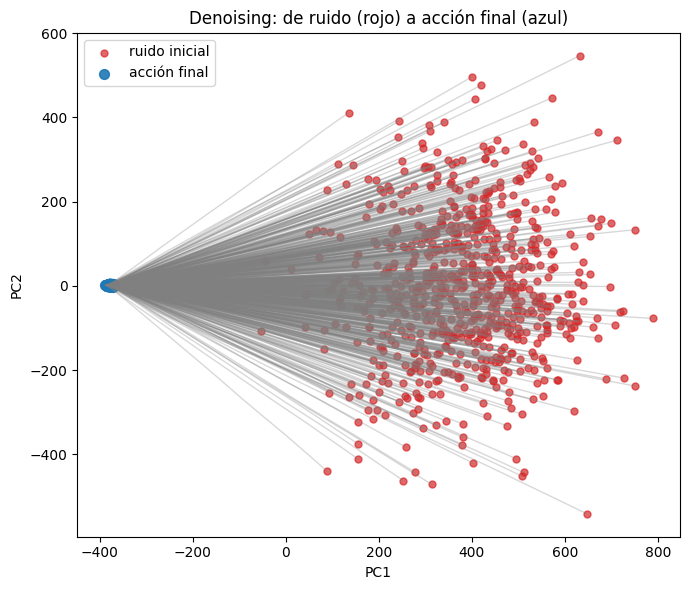

In [23]:
Xall = df[feat_cols].to_numpy(dtype=float)[:, nonconst]
Xall_s = scaler.transform(Xall)            # mismo escalado que las finales
pca_all = PCA(n_components=2, random_state=0)
Zall = pca_all.fit_transform(Xall_s)

proj = df[["call", "iteration"]].copy()
proj["z0"], proj["z1"] = Zall[:, 0], Zall[:, 1]

plt.figure(figsize=(7, 6))
for _, g in proj.groupby("call"):
    g = g.sort_values("iteration")
    plt.plot(g["z0"], g["z1"], "-", color="gray", alpha=0.3, lw=1)
ini = proj[proj["iteration"] == 0]
fin = proj.loc[proj.groupby("call")["iteration"].idxmax()]
plt.scatter(ini["z0"], ini["z1"], s=25, c="tab:red",  alpha=0.7, label="ruido inicial")
plt.scatter(fin["z0"], fin["z1"], s=50, c="tab:blue", alpha=0.9, label="acción final")
plt.legend(); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Denoising: de ruido (rojo) a acción final (azul)")
plt.tight_layout(); plt.show()

## 7. Conclusión

Junta las tres señales:
- **Silhouette** (celda 4): si el mejor `k` supera ~0.5, hay clusters marcados.
- **Dispersión 2D** (PCA / t-SNE): grupos visualmente separados vs. una nube única.
- **Trayectorias** (celda 6): si los puntos azules aterrizan en zonas distintas.

Si no hay clusters claros, la política es prácticamente **unimodal** para ese
input. Si los hay, es **multimodal**: distintas corridas eligen estrategias
distintas desde el mismo estado.

## 8. Animación (GIF) del flow-matching

Un frame por iteración: muestra cómo se mueven los vectores en el plano PCA desde
el **ruido inicial** (iteración 0) hasta las **acciones finales**. Cada punto se
colorea por el cluster al que llega, para ver cómo emergen los grupos.

Guarda el GIF en `output/pi0_denoise/flow_matching.gif` y lo muestra inline.

GIF guardado en: output/pi0_denoise/flow_matching.gif


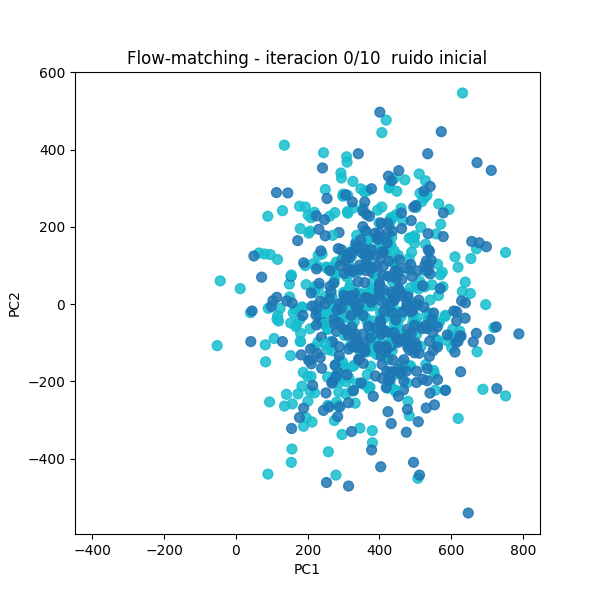

In [24]:
import matplotlib.animation as animation
from IPython.display import Image

# Proyeccion de TODAS las iteraciones (reusa la de la celda 6, o la recomputa).
try:
    proj
except NameError:
    Xall = df[feat_cols].to_numpy(dtype=float)[:, nonconst]
    Zall = PCA(n_components=2, random_state=0).fit_transform(scaler.transform(Xall))
    proj = df[["call", "iteration"]].copy()
    proj["z0"], proj["z1"] = Zall[:, 0], Zall[:, 1]

# Color de cada corrida = su cluster FINAL (para ver como se separan).
call_to_label = dict(zip(finals["call"].to_numpy(), labels))
proj = proj.copy()
proj["cluster"] = proj["call"].map(call_to_label).fillna(0).astype(int)

iters = sorted(proj["iteration"].unique())
pad0 = 0.05 * (proj["z0"].max() - proj["z0"].min() + 1e-9)
pad1 = 0.05 * (proj["z1"].max() - proj["z1"].min() + 1e-9)

fig, ax = plt.subplots(figsize=(6, 6))
scat = ax.scatter([], [], s=50, alpha=0.85, cmap="tab10",
                  c=[], vmin=proj["cluster"].min(), vmax=max(proj["cluster"].max(), 1))
ax.set_xlim(proj["z0"].min() - pad0, proj["z0"].max() + pad0)
ax.set_ylim(proj["z1"].min() - pad1, proj["z1"].max() + pad1)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
title = ax.set_title("")

def update(it):
    g = proj[proj["iteration"] == it]
    scat.set_offsets(g[["z0", "z1"]].to_numpy())
    scat.set_array(g["cluster"].to_numpy())
    t = "ruido inicial" if it == iters[0] else ("accion final" if it == iters[-1] else "")
    title.set_text(f"Flow-matching - iteracion {it}/{iters[-1]}  {t}")
    return scat, title

anim = animation.FuncAnimation(fig, update, frames=iters, interval=300, blit=False)

GIF_PATH = "output/pi0_denoise/flow_matching.gif"
anim.save(GIF_PATH, writer=animation.PillowWriter(fps=3))
plt.close(fig)
print("GIF guardado en:", GIF_PATH)
Image(filename=GIF_PATH)

## 9. UMAP: detección de clusters de los vectores finales

UMAP suele separar clusters no lineales mejor que PCA/t-SNE. Ajustamos UMAP sobre
las **acciones finales** y detectamos clusters en ese embedding (KMeans +
*silhouette*). Este `reducer` se reutiliza luego para el GIF, así el último frame
coincide con este scatter.

> Requiere **`umap-learn`** en el entorno `tipico`:  `pip install umap-learn`.

c:\Users\diego\anaconda3\envs\tipico\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


silhouette (UMAP) por k: {2: np.float32(0.574), 3: np.float32(0.436), 4: np.float32(0.377), 5: np.float32(0.403), 6: np.float32(0.368)}
mejor k = 2  (silhouette = 0.574)


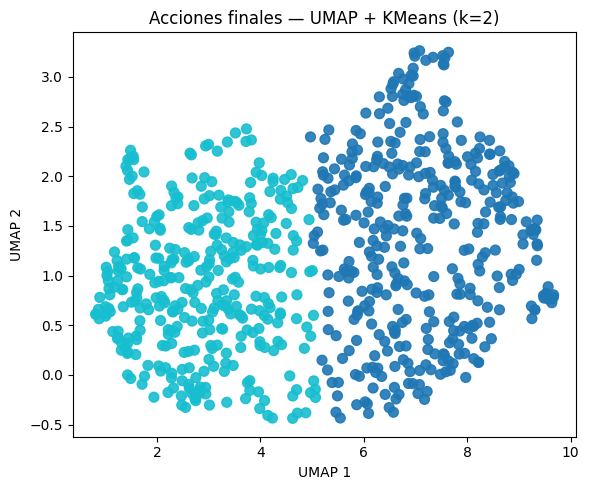

In [25]:
try:
    import umap
except ImportError as e:
    raise ImportError(
        "Falta 'umap-learn' en el entorno 'tipico'. Instala con:  pip install umap-learn"
    ) from e

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

n = X.shape[0]
nn = max(2, min(15, n - 1))                       # n_neighbors debe ser < n_samples
reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=0)
U = reducer.fit_transform(Xs)                     # embedding UMAP de las finales (n, 2)

ks = [k for k in range(2, 7) if k < n]
sil = {k: silhouette_score(U, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(U))
       for k in ks}
print("silhouette (UMAP) por k:", {k: round(v, 3) for k, v in sil.items()})
best_k = max(sil, key=sil.get) if sil else 1
if sil:
    print(f"mejor k = {best_k}  (silhouette = {sil[best_k]:.3f})")

labels_umap = (KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(U)
               if best_k >= 2 else np.zeros(n, dtype=int))

plt.figure(figsize=(6, 5))
plt.scatter(U[:, 0], U[:, 1], c=labels_umap, cmap="tab10", s=50, alpha=0.9)
plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
plt.title(f"Acciones finales — UMAP + KMeans (k={best_k})")
plt.tight_layout(); plt.show()

## 10. GIF del flow-matching en espacio UMAP

Proyectamos **todas** las iteraciones al MISMO espacio UMAP de las finales
(`reducer.transform`) y animamos iteración a iteración. Así el ruido inicial
aparece mapeado dentro del layout de clusters y se ve cómo colapsa hacia ellos;
el último frame coincide con el scatter de la celda 9.

Nota: UMAP es no lineal, así que las trayectorias pueden verse menos suaves que
en PCA (el GIF de la sección 8). UMAP prioriza separar clusters, no preservar el
camino lineal del denoising.

## 11. Estudio por `step`: ¿algún paso es multimodal?

Repite el análisis de clusters de las **acciones finales**, pero **por cada `step`**
del entorno (cada estado en el que se generaron las `N_SAMPLES` muestras). Así
detectamos si la política se vuelve multimodal en ciertos estados.

Para cada step: tomamos las acciones finales (última iteración de cada `call`),
buscamos el mejor `k` con *silhouette* y clasificamos el step como:
**fuerte** (silhouette > 0.50), **débil** (0.25–0.50) o **unimodal** (< 0.25).

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

assert "step" in df.columns, "El CSV no tiene columna 'step'. Regenera con el barrido del notebook de pi0."

def finals_of_step(s):
    sub = df[df["step"] == s]
    fi = sub.groupby("call")["iteration"].transform("max")
    return sub[sub["iteration"] == fi][feat_cols].to_numpy(dtype=float)

def analyze(Xraw, kmax=6):
    std = Xraw.std(axis=0)
    Xr = Xraw[:, std > 1e-8]                       # quita dims constantes
    n = Xr.shape[0]
    out = {"n": n, "best_k": np.nan, "best_sil": np.nan, "veredicto": "pocas muestras"}
    if n < 4 or Xr.shape[1] == 0:
        return out
    Xs = StandardScaler().fit_transform(Xr)
    ks = [k for k in range(2, kmax + 1) if k < n]
    sil = {k: silhouette_score(Xs, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs))
           for k in ks}
    if not sil:
        return out
    bk = max(sil, key=sil.get); bs = sil[bk]
    out.update(best_k=bk, best_sil=round(bs, 3),
               veredicto=("fuerte" if bs > 0.50 else "debil" if bs > 0.25 else "unimodal"))
    return out

steps = sorted(df["step"].unique())
rows = [{"step": s, **analyze(finals_of_step(s))} for s in steps]
per_step = pd.DataFrame(rows).set_index("step")
print("Resumen por step:")
print(per_step[["n", "best_k", "best_sil", "veredicto"]])
multimodal = per_step.index[per_step["veredicto"].isin(["fuerte", "debil"])].tolist()
print("\nSteps con indicios de multimodalidad:", multimodal if multimodal else "ninguno")
per_step

Resumen por step:
       n  best_k  best_sil veredicto
step                                
0     50       2     0.034  unimodal
1     50       2     0.022  unimodal
2     50       2     0.026  unimodal
3     50       2     0.009  unimodal
4     50       2     0.026  unimodal
5     50       2     0.026  unimodal
6     50       2     0.028  unimodal
7     50       2     0.020  unimodal
8     50       2     0.031  unimodal
9     50       3     0.020  unimodal
10    50       2     0.036  unimodal
11    50       2     0.027  unimodal
12    50       2     0.030  unimodal
13    50       2     0.021  unimodal
14    50       2     0.024  unimodal

Steps con indicios de multimodalidad: ninguno


,n,best_k,best_sil,veredicto
step,,,,
0,50,2,0.034,unimodal
1,50,2,0.022,unimodal
2,50,2,0.026,unimodal
3,50,2,0.009,unimodal
4,50,2,0.026,unimodal
5,50,2,0.026,unimodal
6,50,2,0.028,unimodal
7,50,2,0.020,unimodal
8,50,2,0.031,unimodal


### Silhouette por step

Barras sobre la línea 0.50 = clusters fuertes (multimodal claro); entre 0.25 y
0.50 = estructura débil. Encima de cada barra, el mejor `k`.

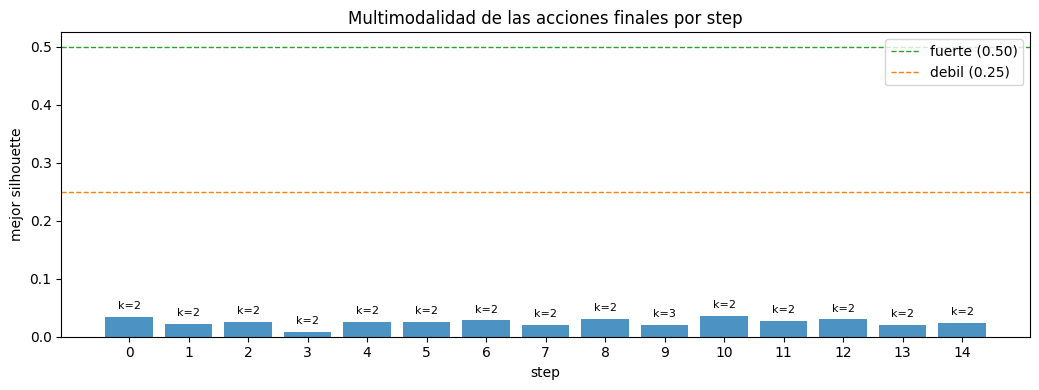

In [27]:
fig, ax = plt.subplots(figsize=(max(6, 0.7 * len(per_step)), 4))
vals = per_step["best_sil"].fillna(0).to_numpy()
xs = np.arange(len(per_step))
bars = ax.bar(xs, vals, color="tab:blue", alpha=0.8)
ax.axhline(0.50, ls="--", c="tab:green", lw=1, label="fuerte (0.50)")
ax.axhline(0.25, ls="--", c="tab:orange", lw=1, label="debil (0.25)")
ax.set_xticks(xs); ax.set_xticklabels(per_step.index)
ax.set_xlabel("step"); ax.set_ylabel("mejor silhouette")
ax.set_title("Multimodalidad de las acciones finales por step")
for x, (_, r) in zip(xs, per_step.iterrows()):
    if not np.isnan(r["best_k"]):
        ax.text(x, (r["best_sil"] or 0) + 0.01, f"k={int(r['best_k'])}",
                ha="center", va="bottom", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

### Proyección 2D (PCA) por step

Una PCA independiente por step, coloreada por los clusters de KMeans (con el mejor
`k` de ese step). Confirma visualmente dónde hay grupos separados.

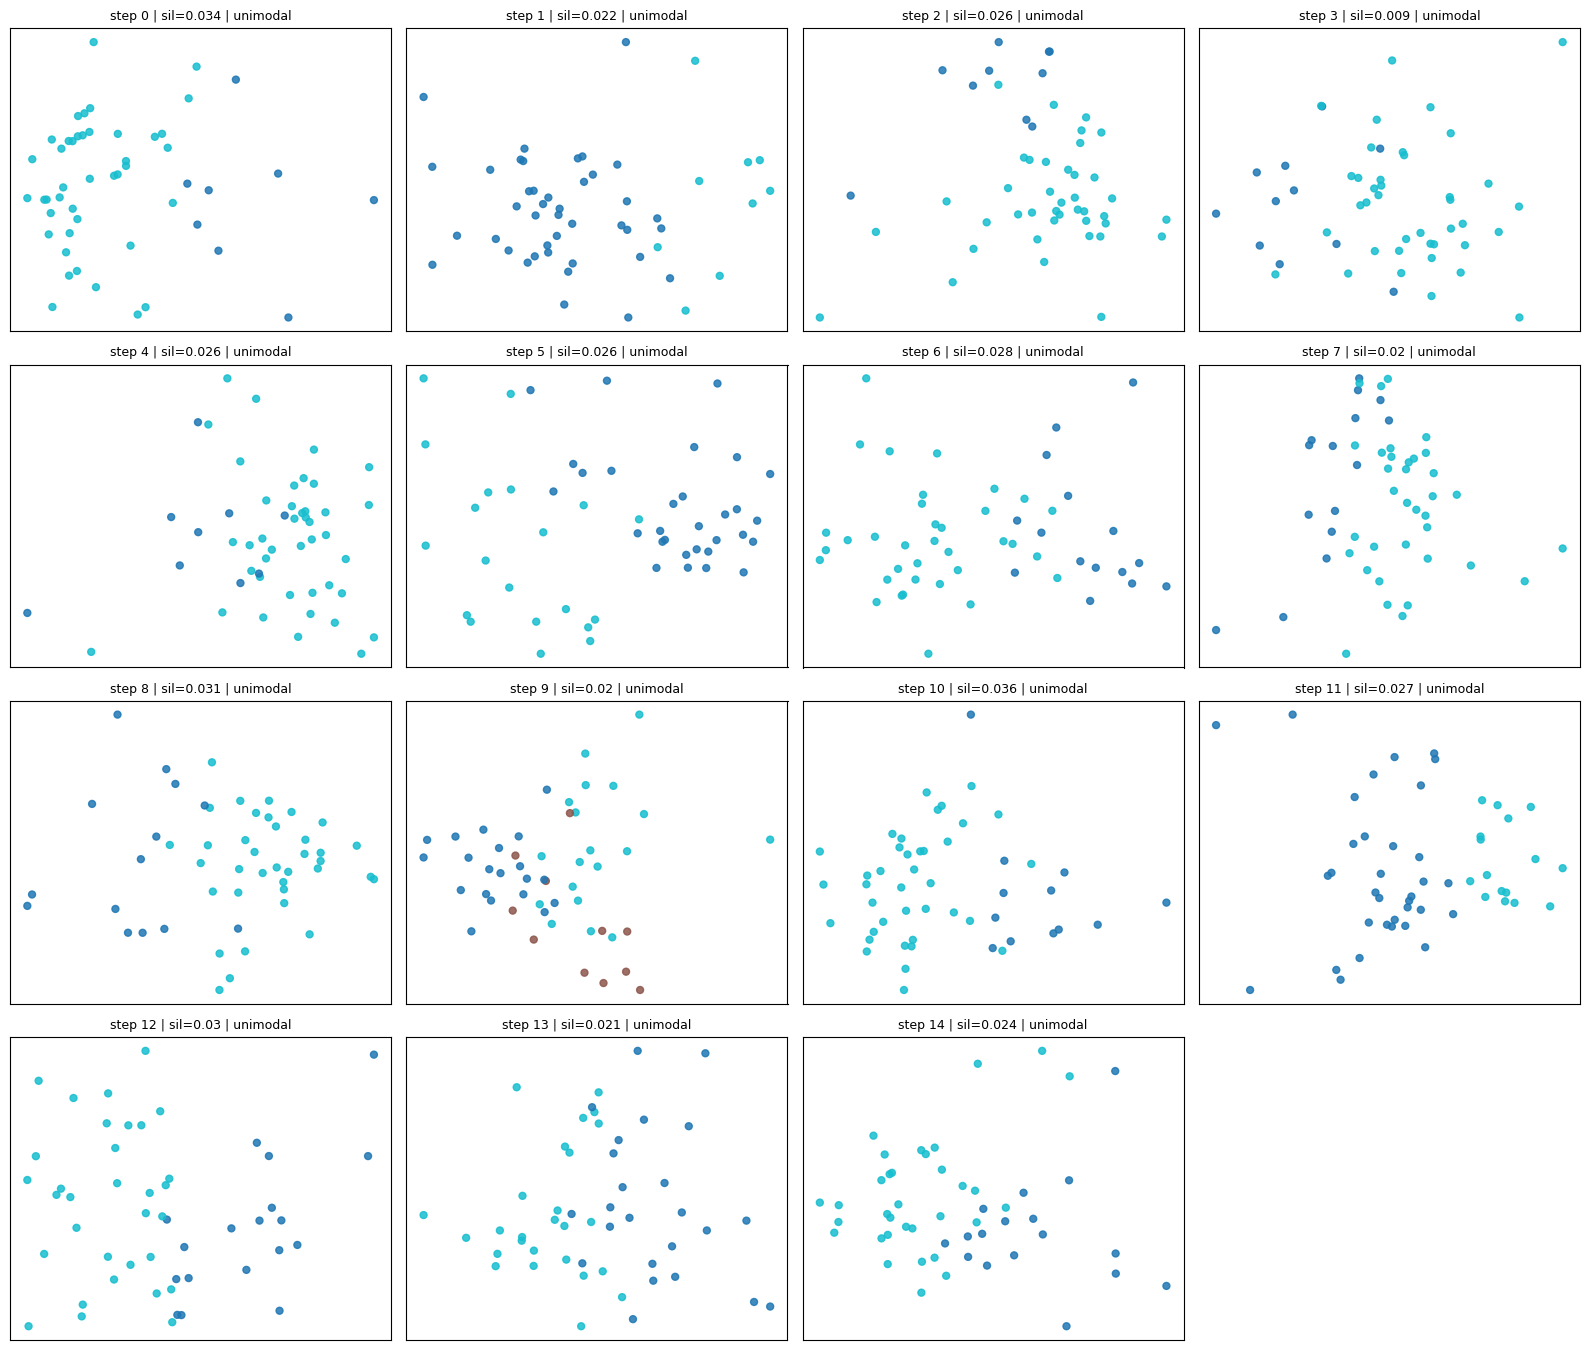

In [28]:
ncols = min(4, len(steps))
nrows = int(np.ceil(len(steps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows), squeeze=False)

for ax, s in zip(axes.ravel(), steps):
    Xraw = finals_of_step(s)
    std = Xraw.std(axis=0); Xr = Xraw[:, std > 1e-8]
    n = Xr.shape[0]
    if n < 2 or Xr.shape[1] == 0:
        ax.set_title(f"step {s} (n={n})"); ax.axis("off"); continue
    Xs = StandardScaler().fit_transform(Xr)
    Z = PCA(n_components=2, random_state=0).fit_transform(Xs)
    bk = per_step.loc[s, "best_k"]
    if not np.isnan(bk) and bk >= 2:
        lab = KMeans(n_clusters=int(bk), n_init=10, random_state=0).fit_predict(Xs)
    else:
        lab = np.zeros(n, dtype=int)
    ax.scatter(Z[:, 0], Z[:, 1], c=lab, cmap="tab10", s=25, alpha=0.85)
    sil = per_step.loc[s, "best_sil"]
    ax.set_title(f"step {s} | sil={sil} | {per_step.loc[s, 'veredicto']}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# apaga ejes sobrantes
for ax in axes.ravel()[len(steps):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### Lectura

- Si **todos** los steps quedan en *unimodal*, la política converge a una acción
  parecida en cada estado (solo variación continua por el ruido).
- Si algún step salta a *fuerte* (o *débil*), ahí la política es **multimodal**:
  desde ese estado elige entre estrategias discretas. Suele pasar en estados
  ambiguos (varios objetos/caminos válidos) o puntos de decisión de la tarea.

> Con `N_SAMPLES=100` por step el silhouette es razonablemente estable; con pocas
> muestras trátalo como orientativo. Para robustez extra, podrías repetir el
> barrido con otra semilla y ver si los mismos steps salen multimodales.